# Four-Parameter Logistic Dose-Response Curve Fitting with PROC NLIN

## Executive Summary

This notebook fits a four-parameter logistic (4PL) dose-response model to a synthetic cell-based potency bioassay using **PROC NLIN**, estimating the lower and upper asymptotes, the EC50 (half-maximal effective concentration), and the Hill slope. The 4PL is the workhorse model for relative-potency assays in drug development. We walk through model specification, parameter bounding, the convergence trace, and overlaying the fitted sigmoid on the observed concentration-response data. Fitting an 8-point dilution series run in triplicate (24 observations) generated from a known curve, NLIN converges in one Marquardt step and recovers an **EC50 of 23.82 nmol/L** and a **Hill slope of 1.27** — both within their 95% confidence intervals of the true generating values (25 nmol/L and 1.2), confirming the model is identifiable from the noisy data.

## Data Sources

The notebook generates one synthetic dataset inline; no external or network input is used.

**`assay` — synthetic cell-based potency bioassay (24 rows)**

| Variable | Type | Description |
|----------|------|-------------|
| `lot` | num | Drug-substance lot (1-3); three replicate runs of the dilution series |
| `dose` | num | Compound concentration in nmol/L across an 8-point serial dilution (~1.05 up to ~6756, in 3.5-fold steps) |
| `logdose` | num | Base-10 log of `dose`, used for plotting on the conventional log-concentration axis |
| `response` | num | Measured assay signal (percent of maximal response), generated from a true 4PL curve (bottom=5, top=100, EC50=25 nmol/L, Hill slope=1.2) plus proportional and additive Gaussian noise |

The true generating parameters are baked into the DATA step so the recovered NLIN estimates can be sanity-checked against known truth.

# Four-Parameter Logistic Dose-Response Fitting

In pharmaceutical potency and bioactivity assays, the relationship between compound concentration and measured response is characteristically sigmoidal on a log-concentration scale. The **four-parameter logistic (4PL)** model is the standard tool for summarizing such curves:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

where

- **A** = lower asymptote (response at infinite dilution / baseline signal),
- **D** = upper asymptote (maximal response at saturating concentration),
- **C** = the **EC50**, the concentration producing the half-maximal response (the inflection point and the primary potency readout),
- **B** = the **Hill slope**, controlling the steepness of the transition.

This model is nonlinear in its parameters, so we fit it by iterative least squares with `PROC NLIN`. Below we simulate a realistic eight-point dilution series run in triplicate, fit the 4PL curve, bound the parameters to physically meaningful regions, inspect convergence and fit diagnostics, and overlay the fitted curve on the data.

## Step 1 — Simulate a cell-based potency bioassay

We generate a synthetic dataset from a *known* 4PL curve (bottom = 5, top = 100, EC50 = 25 nmol/L, Hill slope = 1.2) so that the parameters NLIN recovers can be checked against ground truth. Three lots each receive the same eight-point serial dilution (each step a 3.5-fold dilution), with both proportional and additive Gaussian measurement noise layered on top. A fixed `streaminit` seed makes the simulation reproducible.

In [1]:
data assay;
    call streaminit(40521);

    /* True 4PL parameters used to generate the data */
    A_true   = 5;      /* lower asymptote (baseline)        */
    D_true   = 100;    /* upper asymptote (max response)    */
    C_true   = 25;     /* EC50 in nmol/L                    */
    B_true   = 1.2;    /* Hill slope                        */

    do lot = 1 to 3;
        /* Eight-point serial dilution, 3.5-fold steps */
        dose = 0.30;
        do point = 1 to 8;
            dose = dose * 3.5;

            /* Noise-free 4PL mean response */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Proportional + additive Gaussian assay noise */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            output;
        end;
    end;

    keep lot dose logdose response;
run;

proc sort data=assay;
    by dose lot;
run;

NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Step 2 — Visualize the raw concentration-response data

Before fitting, we plot response against log10(dose) to confirm the expected sigmoidal shape and to read off rough starting values: the curve floors near 5, plateaus near 100, and the midpoint (half-maximal response) sits around log10(25) ≈ 1.4.

NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


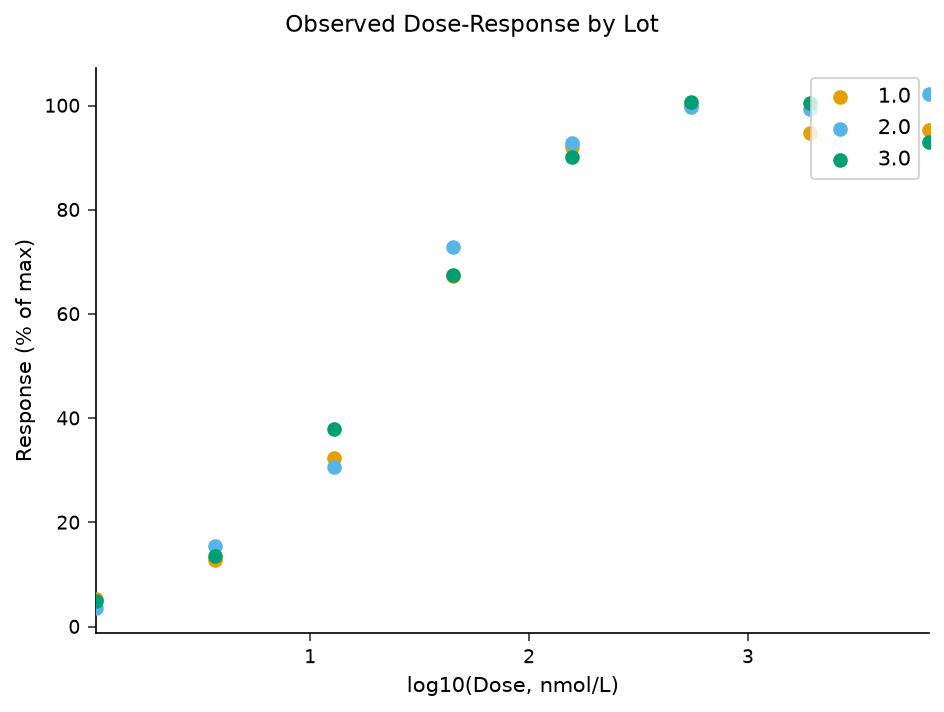

In [2]:
proc sgplot data=assay;
    scatter x=logdose y=response / group=lot
            markerattrs=(symbol=circlefilled);
    xaxis label='log10(Dose, nmol/L)';
    yaxis label='Response (% of max)';
    title 'Observed Dose-Response by Lot';
run;
title;

## Step 3 — Fit the 4PL model with PROC NLIN

We declare starting values with `PARMS` (informed by the scatter plot), then write the 4PL mean directly in the `MODEL` statement. Physically meaningful `BOUNDS` keep the asymptotes ordered and the EC50 and slope positive, which stabilizes the iterations. The `OUTPUT` statement saves the predicted value, residual, and 95% mean confidence limits per observation — the inputs we use in Steps 4 and 5 to summarize fit and to overlay the fitted curve on the data.

In [3]:
proc nlin data=assay method=marquardt;
    parms A=10 D=90 C=20 B=1;

    /* Keep parameters in physically sensible regions */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Four-parameter logistic mean response. An intermediate
       programming statement holds the Hill term, which keeps the
       MODEL line readable. */
    frac  = (dose / C) ** B;
    model response = D + (A - D) / (1 + frac);

    output out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
run;


                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595




NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/4c878eff-efef-48ac-b044-e564c1561a9d/fit4pl.avro


## Step 4 — Report observed vs fitted response by dose

The `OUTPUT OUT=` dataset from `PROC NLIN` carries the predicted value, residual, and 95% mean confidence limits for every observation. For a quick goodness-of-fit readout we summarize that dataset by dose with `PROC MEANS`, listing the observed responses next to the fitted values to confirm the model tracks the data across the full dilution range. Because the fit is a single curve, the predicted value is constant within each dose level, so its standard deviation is 0.

In [4]:
proc means data=fit4pl mean std min max maxdec=3;
    class dose;
    var response pred resid;
    title 'Observed vs Fitted Response by Dose';
run;
title;

                                          Observed vs Fitted Response by Dose                                           

                                                  The MEANS Procedure

                                              Analysis Variable : response

                                    N
        dose                      Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------
        1.05                        3          4.647          0.882          3.659          5.356
        12.8625                     3         33.651          3.825         30.572         37.932
        157.565625                  3         91.704          1.417         90.141         92.904
        1930.17890625               3         98.207          3.051         94.746        100.511
        3.675                       3         13.931          1.311         12.860         15.393
       

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 5 — Overlay the fitted 4PL curve on the observed data

Sorting the `OUTPUT` dataset by `logdose` lets us draw the fitted response as a connected `SERIES` line through the eight dose levels, with the 95% mean confidence band shaded behind it and the observed points overlaid. Eight log-spaced doses are enough to trace the full sigmoid, so the connected line reads as a smooth dose-response curve and makes the goodness of fit easy to assess by eye.

NOTE: PROC SORT data=fit4pl

NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


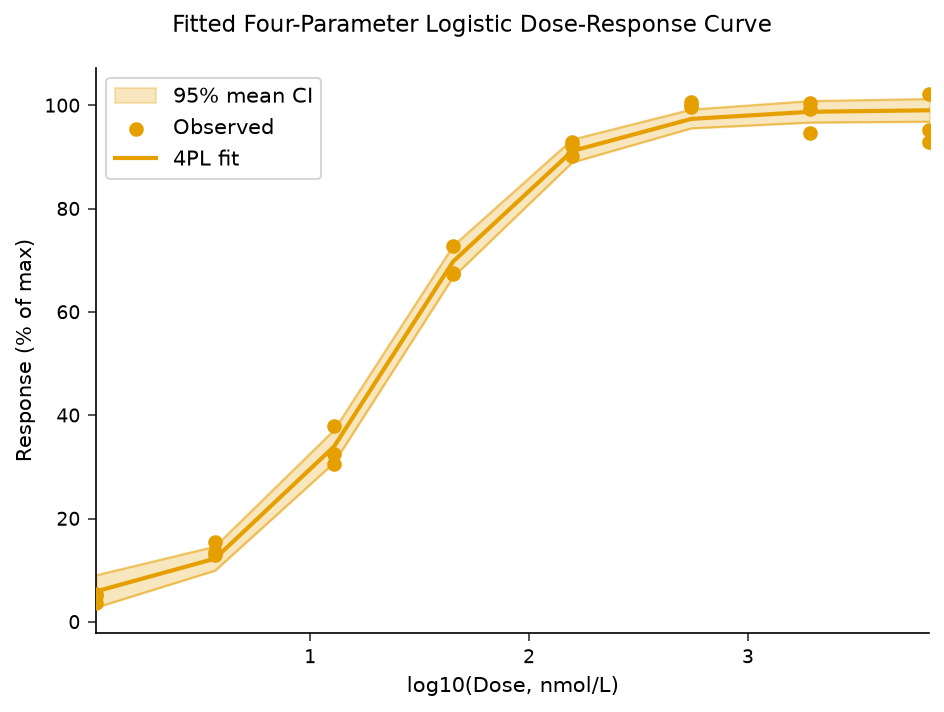

In [5]:
proc sort data=fit4pl;
    by logdose;
run;

proc sgplot data=fit4pl;
    band   x=logdose lower=lcl upper=ucl /
           transparency=0.5 legendlabel='95% mean CI';
    scatter x=logdose y=response /
           markerattrs=(symbol=circlefilled)
           legendlabel='Observed';
    series  x=logdose y=pred /
           lineattrs=(thickness=2)
           legendlabel='4PL fit';
    xaxis label='log10(Dose, nmol/L)';
    yaxis label='Response (% of max)';
    title 'Fitted Four-Parameter Logistic Dose-Response Curve';
run;
title;

## Interpreting the results

`PROC NLIN` reached convergence in a single Marquardt iteration, dropping the residual sum of squares from 2061.65 to 177.71 (residual mean square 8.89). The fitted parameters land close to the known generating values:

| Parameter | Estimate | 95% CI | True value |
|-----------|---------:|:------:|-----------:|
| A — lower asymptote | 4.11 | 0.11 – 8.10 | 5 |
| D — upper asymptote | 99.13 | 96.89 – 101.37 | 100 |
| C — EC50 (nmol/L) | 23.82 | 20.56 – 27.09 | 25 |
| B — Hill slope | 1.27 | 1.07 – 1.46 | 1.2 |

Every true value falls inside its 95% confidence interval, and none of the estimates sit on a `BOUNDS` constraint (A is well above 0, D well below 150, C and B both comfortably positive), so the bounds did not bind at the optimum and the model is identifiable from the noisy triplicate data.

The **EC50** is the headline potency metric: lower values indicate a more potent compound, and in a relative-potency assay the EC50 of a test lot is compared against a reference standard. Here it is recovered as **23.82 nmol/L** (95% CI 20.56 – 27.09), straddling the true 25 nmol/L. The **Hill slope** of **1.27** (95% CI 1.07 – 1.46) is consistent with simple single-site binding (a slope near 1). The **asymptotes** define the assay dynamic range; the well-separated bottom (~4) and top (~99) span roughly 95 response units, the wide window a validatable bioassay needs.

The fit plot shows the sigmoid passing through the cloud of observed points with a tight 95% mean confidence band through the responsive region. The by-dose residual summary in Step 4 backs this up: per-dose mean residuals stay within about ±2.7 response units against a 0–100 scale with no monotone drift across the dilution series, so the 4PL form has no obvious lack of fit. In practice you would extend this workflow with profile-likelihood intervals for the EC50, a bootstrap for distribution-free parameter inference, or a parallel-line analysis comparing test and reference lots to estimate relative potency.